In [2]:
import os
import pandas as pd
import numpy as np

# 1. Dynamically locate the portfolio-optimization root folder
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_dir = os.path.join(BASE_DIR, "data", "processed")

returns_path = os.path.join(data_dir, "daily_returns.csv")
forecast_path = os.path.join(data_dir, "tsla_future_forecast.csv")

# 2. Ingest data files safely
returns_df = pd.read_csv(returns_path, index_col=0, parse_dates=True)

# Read forecast file and force rows containing strings to convert to NaN, then drop them
tsla_forecast = pd.read_csv(forecast_path, header=None, names=['Date', 'Price'])

# CRITICAL FIX: Force the 'Price' column to be numeric. Mismatched strings automatically turn to NaN
tsla_forecast['Price'] = pd.to_numeric(tsla_forecast['Price'], errors='coerce')
tsla_forecast = tsla_forecast.dropna().reset_index(drop=True)

# 3. Calculate Returns Vector
tsla_start_val = tsla_forecast['Price'].iloc[0]
tsla_end_val = tsla_forecast['Price'].iloc[-1]
tsla_expected_return = (tsla_end_val - tsla_start_val) / tsla_start_val

spy_expected_return = returns_df['SPY'].mean() * 252
bnd_expected_return = returns_df['BND'].mean() * 252

expected_returns = np.array([bnd_expected_return, spy_expected_return, tsla_expected_return])
assets = ['BND', 'SPY', 'TSLA']

print("=== EXPECTED ANNUALIZED RETURNS VECTOR ===")
for asset, ret in zip(assets, expected_returns):
    print(f"{asset}: {ret*100:.2f}%")

=== EXPECTED ANNUALIZED RETURNS VECTOR ===
BND: -1.11%
SPY: 17.69%
TSLA: 0.15%


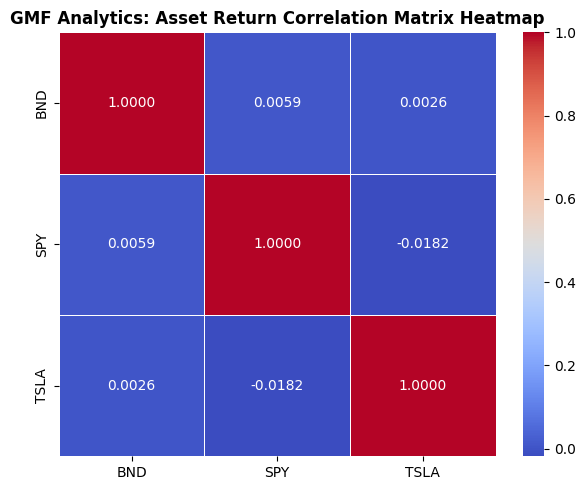

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5)
plt.title("GMF Analytics: Asset Return Correlation Matrix Heatmap", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
import sys
import os

# Ensure the scripts directory is in your path
sys.path.append(os.path.abspath('../'))

# Explicitly import the functions from your scripts folder
from scripts.forecast_models import optimize_portfolio, calculate_portfolio_performance

print("✅ Optimization functions successfully imported!")

✅ Optimization functions successfully imported!


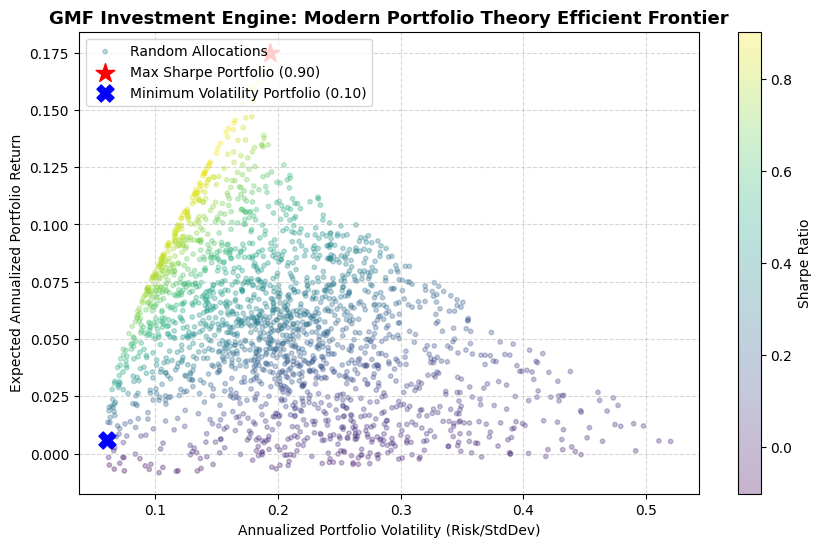

In [9]:
# Optimize the two target portfolios
max_sharpe_w = optimize_portfolio(expected_returns, cov_matrix, objective='sharpe')
min_vol_w = optimize_portfolio(expected_returns, cov_matrix, objective='volatility')

# Calculate explicit performance profiles
max_s_ret, max_s_vol, max_s_sr = calculate_portfolio_performance(max_sharpe_w, expected_returns, cov_matrix)
min_v_ret, min_v_vol, min_v_sr = calculate_portfolio_performance(min_vol_w, expected_returns, cov_matrix)

# Simulate 2,000 random portfolios to plot the full Efficient Frontier cloud
num_portfolios = 2000
results = np.zeros((3, num_portfolios))
np.random.seed(42)

for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)
    p_ret, p_vol, _ = calculate_portfolio_performance(weights, expected_returns, cov_matrix)
    results[0, i] = p_vol
    results[1, i] = p_ret
    results[2, i] = p_ret / p_vol

# Plot optimization boundaries
plt.figure(figsize=(10, 6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3, label='Random Allocations')
plt.colorbar(label='Sharpe Ratio')

# Highlight our target key milestone portfolios
plt.scatter(max_s_vol, max_s_ret, color='red', marker='*', s=200, label=f'Max Sharpe Portfolio ({max_s_sr:.2f})')
plt.scatter(min_v_vol, min_v_ret, color='blue', marker='X', s=150, label=f'Minimum Volatility Portfolio ({min_v_sr:.2f})')

plt.title("GMF Investment Engine: Modern Portfolio Theory Efficient Frontier", fontsize=13, fontweight='bold')
plt.xlabel("Annualized Portfolio Volatility (Risk/StdDev)")
plt.ylabel("Expected Annualized Portfolio Return")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
recommendation_data = {
    "Allocation Asset Weights": [
        f"BND: {max_sharpe_w[0]*100:.1f}% | SPY: {max_sharpe_w[1]*100:.1f}% | TSLA: {max_sharpe_w[2]*100:.1f}%",
        f"BND: {min_vol_w[0]*100:.1f}% | SPY: {min_vol_w[1]*100:.1f}% | TSLA: {min_vol_w[2]*100:.1f}%"
    ],
    "Expected Annual Return": [f"{max_s_ret*100:.2f}%", f"{min_v_ret*100:.2f}%"],
    "Expected Volatility": [f"{max_s_vol*100:.2f}%", f"{min_v_vol*100:.2f}%"],
    "Sharpe Ratio": [round(max_s_sr, 2), round(min_v_sr, 2)]
}

summary_df = pd.DataFrame(recommendation_data, index=["Maximum Sharpe Portfolio (Recommended)", "Minimum Volatility Portfolio"])
display(summary_df)

,Allocation Asset Weights,Expected Annual Return,Expected Volatility,Sharpe Ratio
Maximum Sharpe Portfolio (Recommended),BND: 0.2% | SPY: 98.9% | TSLA: 0.9%,17.49%,19.34%,0.9
Minimum Volatility Portfolio,BND: 89.7% | SPY: 9.1% | TSLA: 1.2%,0.61%,6.06%,0.1
